# World Cup Matches — Exploratory Data Analysis

This notebook explores international World Cup matches from 1930–2022. The goal is to understand data quality, match outcomes, scoring patterns, tournament stages, host advantage, team confederations, and relationships that may be useful for later modeling.

The primary dataset contains match-level records (`matches_1930_2022.csv`). The secondary dataset (`Rating_wc.csv`) contains tournament-level information and is inspected separately where applicable.


## 1. Data dictionary

| Column | Meaning |
|---|---|
| `home_team`, `away_team` | Teams listed on each side of the match |
| `home_score`, `away_score` | Goals scored in the match |
| `Round` | Tournament stage or match round |
| `Host` | Country hosting the tournament |
| `Attendance` | Recorded attendance, where available |
| `home_xg`, `away_xg` | Expected goals, available only for more recent matches |
| `home_penalty`, `away_penalty` | Penalty-shootout information, where available |

The target variables created below are `result` (home win/draw/away win) and `home_win` (binary home win).

## 2. Dataset overview and data quality

In [14]:
# Import the libraries needed for the analysis.
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

%matplotlib inline

In [15]:
# Load the World Cup dataset.
#Load the data
df = pd.read_csv('../data/raw/matches_1930_2022.csv')
df2 = pd.read_csv('../data/raw/Rating_wc.csv', names=['Year','Team','Final_Position','Eliminated_Round'], header=0)
from IPython.display import display
display(df.head())
display(df2.head())



,home_team,away_team,home_score,home_xg,home_penalty,away_score,away_xg,away_penalty,home_manager,home_captain,...,home_penalty_shootout_miss_long,away_penalty_shootout_miss_long,home_red_card,away_red_card,home_yellow_red_card,away_yellow_red_card,home_yellow_card_long,away_yellow_card_long,home_substitute_in_long,away_substitute_in_long
0,Argentina,France,3,3.3,4.0,3,2.2,2.0,Lionel Scaloni,Lionel Messi,...,NaN,"['3|1:1|Kingsley Coman', '5|2:1|Aurélien Tchou...",NaN,NaN,NaN,NaN,"['45+7&rsquor;|2:0|Enzo Fernández', '90+8&rsqu...","['55&rsquor;|2:0|Adrien Rabiot', '87&rsquor;|2...",['64&rsquor;|2:0|Marcos Acuña|for Ángel Di Mar...,['41&rsquor;|2:0|Randal Kolo Muani|for Ousmane...
1,Croatia,Morocco,2,0.7,NaN,1,1.2,NaN,Zlatko Dalić,Luka Modrić,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['69&rsquor;|2:1|Azzedine Ounahi', '84&rsquor;...",['61&rsquor;|2:1|Nikola Vlašić|for Andrej Kram...,['46&rsquor;|2:1|Ilias Chair|for Abdelhamid Sa...
2,France,Morocco,2,2.0,NaN,0,0.9,NaN,Didier Deschamps,Hugo Lloris,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['27&rsquor;|1:0|Sofiane Boufal'],['65&rsquor;|1:0|Marcus Thuram|for Olivier Gir...,['21&rsquor;|1:0|Selim Amallah|for Romain Saïs...
3,Argentina,Croatia,3,2.3,NaN,0,0.5,NaN,Lionel Scaloni,Lionel Messi,...,NaN,NaN,NaN,NaN,NaN,NaN,"['68&rsquor;|2:0|Cristian Romero', '71&rsquor;...","['32&rsquor;|0:0|Mateo Kovačić', '32&rsquor;|0...",['62&rsquor;|2:0|Lisandro Martínez|for Leandro...,"['46&rsquor;|2:0|Mislav Oršić|for Borna Sosa',..."
4,Morocco,Portugal,1,1.4,NaN,0,0.9,NaN,Hoalid Regragui,Romain Saïss,...,NaN,NaN,NaN,NaN,Walid Cheddira · 90+3,NaN,"['70&rsquor;|1:0|Achraf Dari', '90+1&rsquor;|1...",['87&rsquor;|1:0|Vitinha'],['57&rsquor;|1:0|Achraf Dari|for Romain Saïss'...,['51&rsquor;|1:0|João Cancelo|for Raphaël Guer...


,Year,Host,Teams,Champion,Runner-Up,TopScorrer,Attendance,AttendanceAvg,Matches
0,2022,Qatar,32,Argentina,France,Kylian Mbappé - 8,3404252,53191,64
1,2018,Russia,32,France,Croatia,Harry Kane - 6,3031768,47371,64
2,2014,Brazil,32,Germany,Argentina,James Rodríguez - 6,3429873,53592,64
3,2010,South Africa,32,Spain,Netherlands,"Wesley Sneijder, Thomas Müller... - 5",3178856,49670,64
4,2006,Germany,32,Italy,France,Miroslav Klose - 5,3352605,52384,64


In [16]:
# Review the dataset structure and basic information.
#Dataset Overview
display(df.info())
display(df2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 964 entries, 0 to 963
Data columns (total 44 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   home_team                        964 non-null    object 
 1   away_team                        964 non-null    object 
 2   home_score                       964 non-null    int64  
 3   home_xg                          128 non-null    float64
 4   home_penalty                     35 non-null     float64
 5   away_score                       964 non-null    int64  
 6   away_xg                          128 non-null    float64
 7   away_penalty                     35 non-null     float64
 8   home_manager                     964 non-null    object 
 9   home_captain                     644 non-null    object 
 10  away_manager                     964 non-null    object 
 11  away_captain                     644 non-null    object 
 12  Attendance            

None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Year           22 non-null     int64 
 1   Host           22 non-null     object
 2   Teams          22 non-null     int64 
 3   Champion       22 non-null     object
 4   Runner-Up      22 non-null     object
 5   TopScorrer     22 non-null     object
 6   Attendance     22 non-null     int64 
 7   AttendanceAvg  22 non-null     int64 
 8   Matches        22 non-null     int64 
dtypes: int64(5), object(4)
memory usage: 1.7+ KB


None

In [17]:
# Summarize missing values across the dataset.
#Missing Values Analysis
from IPython.display import display

def missing_report(df, name):
    missing = pd.DataFrame({
        "Missing Count": df.isnull().sum(),
        "Missing %": (df.isnull().sum() / len(df) * 100).round(2)
    })
    missing = missing[missing["Missing Count"] > 0].sort_values("Missing %", ascending=False)
    print(f"\n=== {name} — columns with missing values ===")
    display(missing)

missing_report(df, "matches")
missing_report(df2, "playoff_team_results")


=== matches — columns with missing values ===


,Missing Count,Missing %
home_penalty_miss_long,958,99.38
away_penalty_miss_long,955,99.07
away_own_goal,947,98.24
home_yellow_red_card,941,97.61
home_penalty_shootout_miss_long,940,97.51
away_penalty_shootout_miss_long,934,96.89
away_yellow_red_card,933,96.78
home_penalty_shootout_goal_long,930,96.47
away_penalty_shootout_goal_long,930,96.47
away_penalty,929,96.37



=== world_cup — columns with missing values ===


,Missing Count,Missing %


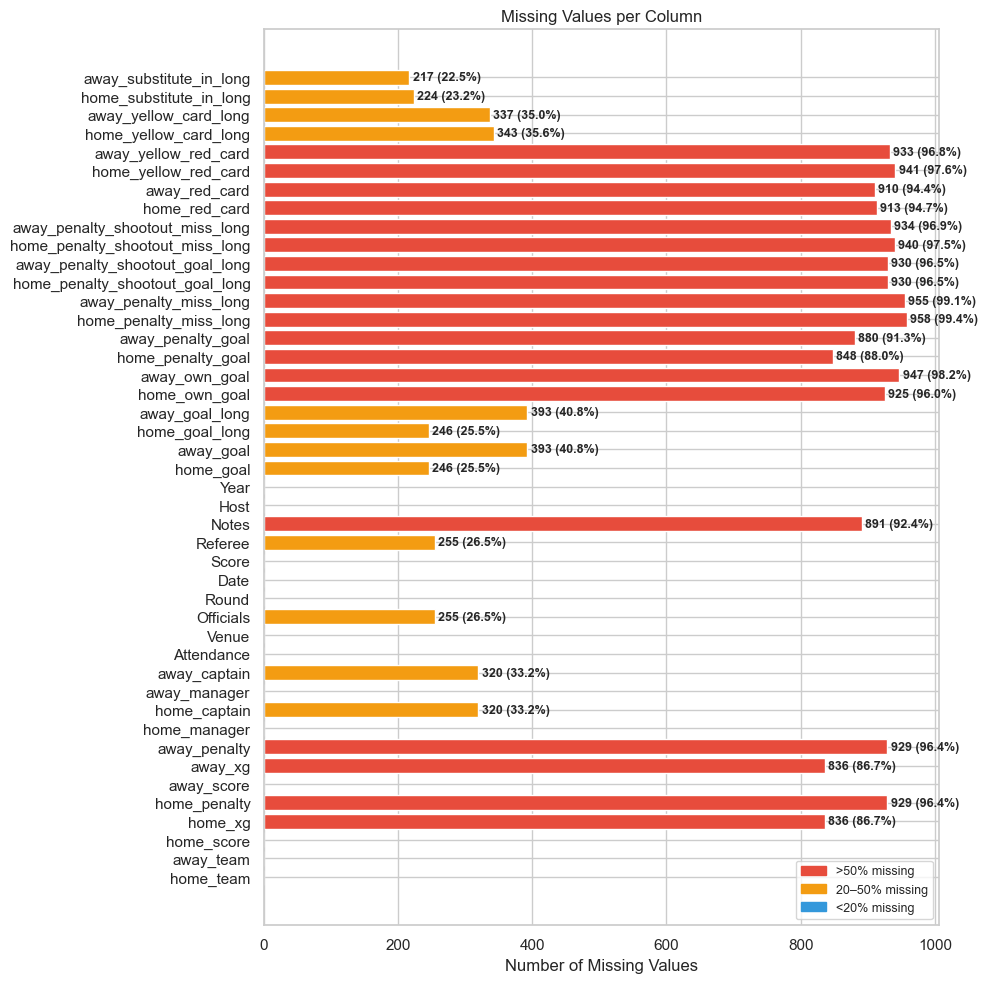

In [18]:
# Visualize missing values in the dataset.
# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 10))

def color_for(col):
    pct = df[col].isnull().mean()
    if pct > 0.5:
        return "#e74c3c"
    elif pct >= 0.2:
        return "#f39c12" 
    else:
        return "#3498db" 

colors = [color_for(col) for col in df.columns]

missing_counts = df.isnull().sum()

ax.barh(df.columns, missing_counts, color=colors)
ax.set_xlabel("Number of Missing Values")
ax.set_title("Missing Values per Column")

for i, (col, v) in enumerate(missing_counts.items()):
    if v > 0:
        pct = v / len(df) * 100
        ax.text(v + 5, i, f"{v} ({pct:.1f}%)", va="center", fontweight="bold", fontsize=9)

from matplotlib.patches import Patch
legend_elems = [
    Patch(color="#e74c3c", label=">50% missing"),
    Patch(color="#f39c12", label="20–50% missing"),
    Patch(color="#3498db", label="<20% missing"),
]
ax.legend(handles=legend_elems, loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

In [19]:
# Prepare numerical variables for analysis.
import numpy as np

# Target 1 — (H/D/A)
df["result"] = np.select(
    [df.home_score > df.away_score,
     df.home_score == df.away_score],
    ["H", "D"], default="A"
)

# Target 2 — (home_win)
df["home_win"] = (df.home_score > df.away_score).astype(int)
print(df.columns.tolist())
print(df[["home_score", "away_score", "result", "home_win"]].head())

['home_team', 'away_team', 'home_score', 'home_xg', 'home_penalty', 'away_score', 'away_xg', 'away_penalty', 'home_manager', 'home_captain', 'away_manager', 'away_captain', 'Attendance', 'Venue', 'Officials', 'Round', 'Date', 'Score', 'Referee', 'Notes', 'Host', 'Year', 'home_goal', 'away_goal', 'home_goal_long', 'away_goal_long', 'home_own_goal', 'away_own_goal', 'home_penalty_goal', 'away_penalty_goal', 'home_penalty_miss_long', 'away_penalty_miss_long', 'home_penalty_shootout_goal_long', 'away_penalty_shootout_goal_long', 'home_penalty_shootout_miss_long', 'away_penalty_shootout_miss_long', 'home_red_card', 'away_red_card', 'home_yellow_red_card', 'away_yellow_red_card', 'home_yellow_card_long', 'away_yellow_card_long', 'home_substitute_in_long', 'away_substitute_in_long', 'result', 'home_win']
   home_score  away_score result  home_win
0           3           3      D         0
1           2           1      H         1
2           2           0      H         1
3           3      

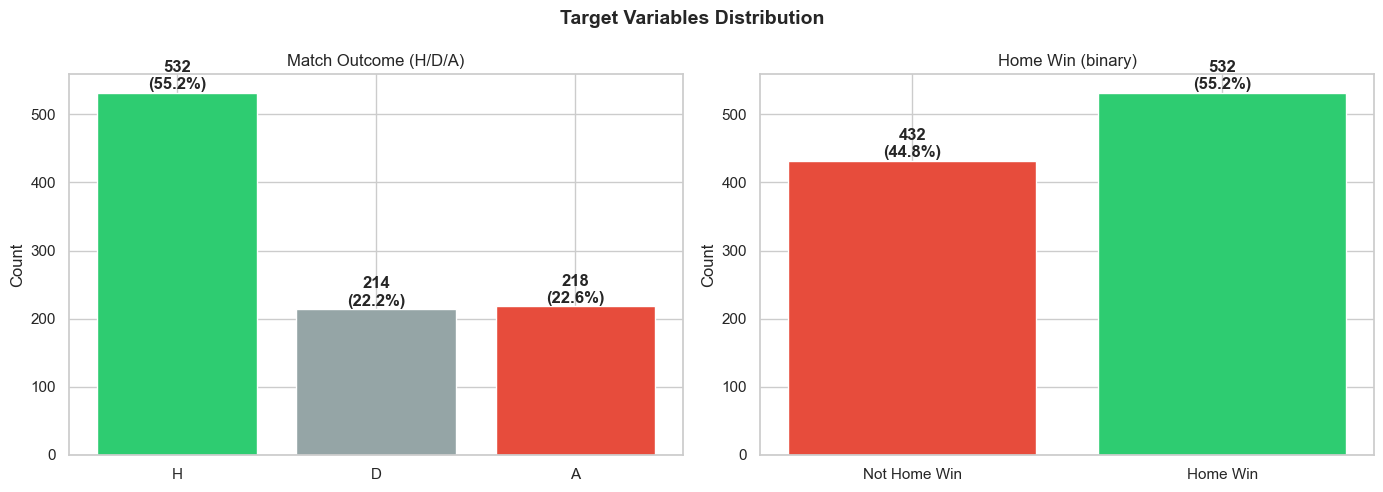

Baseline accuracy (always H): 55.19%
Home win rate:                55.19%


In [20]:
# Explore the distribution of the main numerical variables.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Основной target: result (H/D/A) ---
result_counts = df["result"].value_counts().reindex(["H", "D", "A"])
colors = ["#2ecc71", "#95a5a6", "#e74c3c"]
axes[0].bar(result_counts.index, result_counts.values, color=colors)
axes[0].set_title("Match Outcome (H/D/A)")
axes[0].set_ylabel("Count")
for i, v in enumerate(result_counts.values):
    pct = v / len(df) * 100
    axes[0].text(i, v + 5, f"{v}\n({pct:.1f}%)", ha="center", fontweight="bold")

# --- Вторичный target: home_win (0/1) ---
hw_counts = df["home_win"].value_counts().reindex([0, 1])
axes[1].bar(["Not Home Win", "Home Win"], hw_counts.values,
            color=["#e74c3c", "#2ecc71"])
axes[1].set_title("Home Win (binary)")
axes[1].set_ylabel("Count")
for i, v in enumerate(hw_counts.values):
    pct = v / len(df) * 100
    axes[1].text(i, v + 5, f"{v}\n({pct:.1f}%)", ha="center", fontweight="bold")

plt.suptitle("Target Variables Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Сводка
print(f"Baseline accuracy (always H): {(df.result == 'H').mean():.2%}")
print(f"Home win rate:                {df.home_win.mean():.2%}")

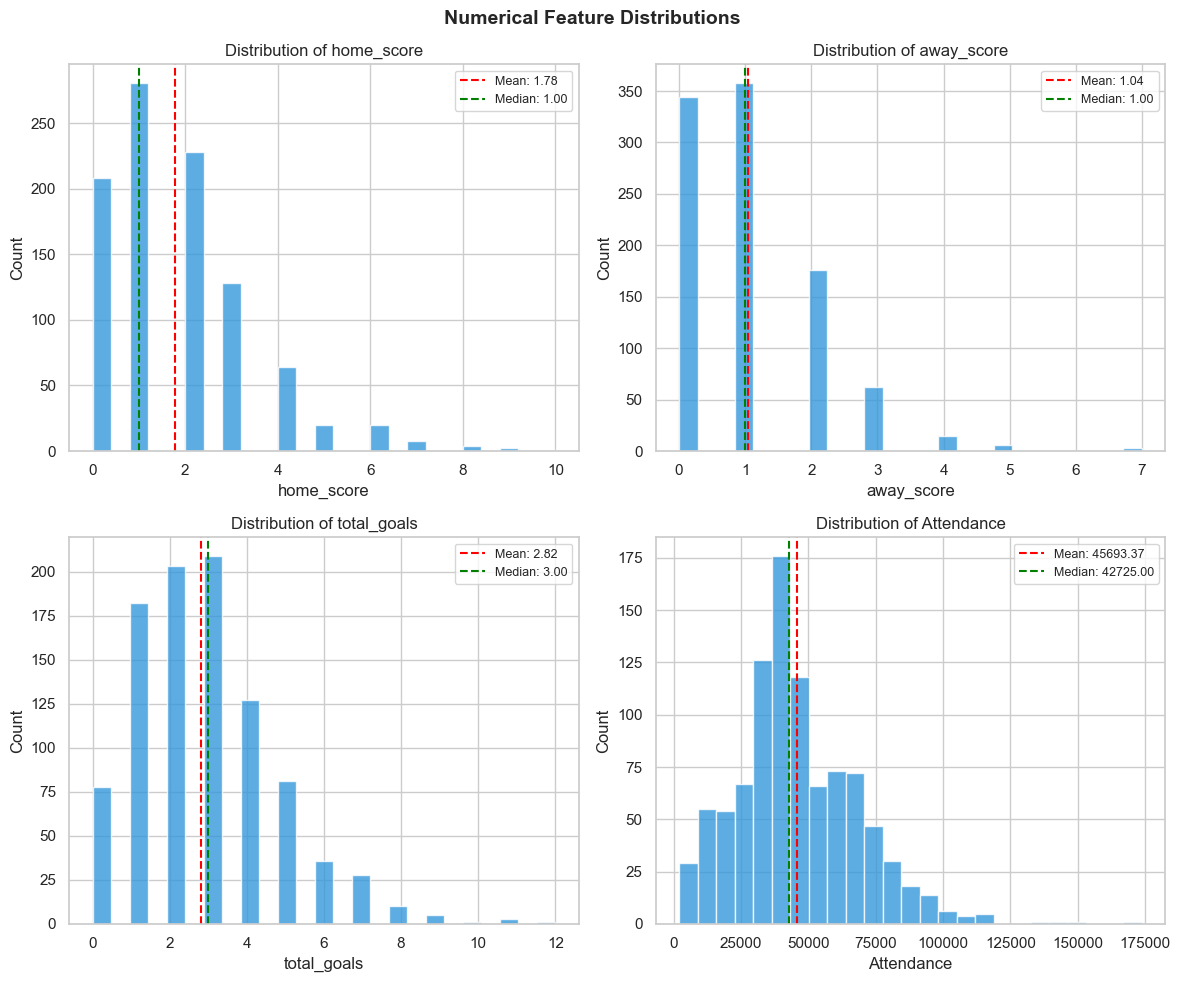

In [21]:
# Select numerical features for further analysis.
df["total_goals"] = df["home_score"] + df["away_score"]

numerical_cols = ["home_score", "away_score", "total_goals", "Attendance"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=25, color="#3498db", edgecolor="white", alpha=0.8)
    axes[i].axvline(data.mean(),   color="red",   linestyle="--",
                    label=f"Mean: {data.mean():.2f}")
    axes[i].axvline(data.median(), color="green", linestyle="--",
                    label=f"Median: {data.median():.2f}")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].legend(fontsize=9)

plt.suptitle("Numerical Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [22]:
# Define the configuration used for the visualizations.
conf = {
    "UEFA":     ["Germany","Italy","France","Spain","England","Netherlands","Portugal","Belgium","Croatia","Switzerland","Sweden","Denmark","Poland","Serbia","Austria","Hungary","Czechoslovakia","Yugoslavia","Romania","Russia","Soviet Union","West Germany","Scotland","Wales","Northern Ireland","Norway","Slovakia","Slovenia","Turkey","Türkiye","Greece","Bulgaria","Ukraine","Republic of Ireland","Iceland"],
    "CONMEBOL": ["Brazil","Argentina","Uruguay","Chile","Colombia","Peru","Paraguay","Ecuador","Bolivia"],
    "CAF":      ["Morocco","Senegal","Cameroon","Nigeria","Ghana","Algeria","Tunisia","Egypt","South Africa","Côte d'Ivoire","Zaire","Angola","Togo"],
    "AFC":      ["Japan","Korea Republic","Saudi Arabia","IR Iran","Australia","China PR","Korea DPR","Qatar","United Arab Emirates","Iraq","Kuwait","Dutch East Indies"],
    "CONCACAF": ["Mexico","United States","Costa Rica","Honduras","Canada","Jamaica","El Salvador","Cuba","Trinidad and Tobago","Haiti","Panama"],
}
df["Confederation"] = df["home_team"].apply(
    lambda t: next((c for c, teams in conf.items() if t in teams), "Other")
)

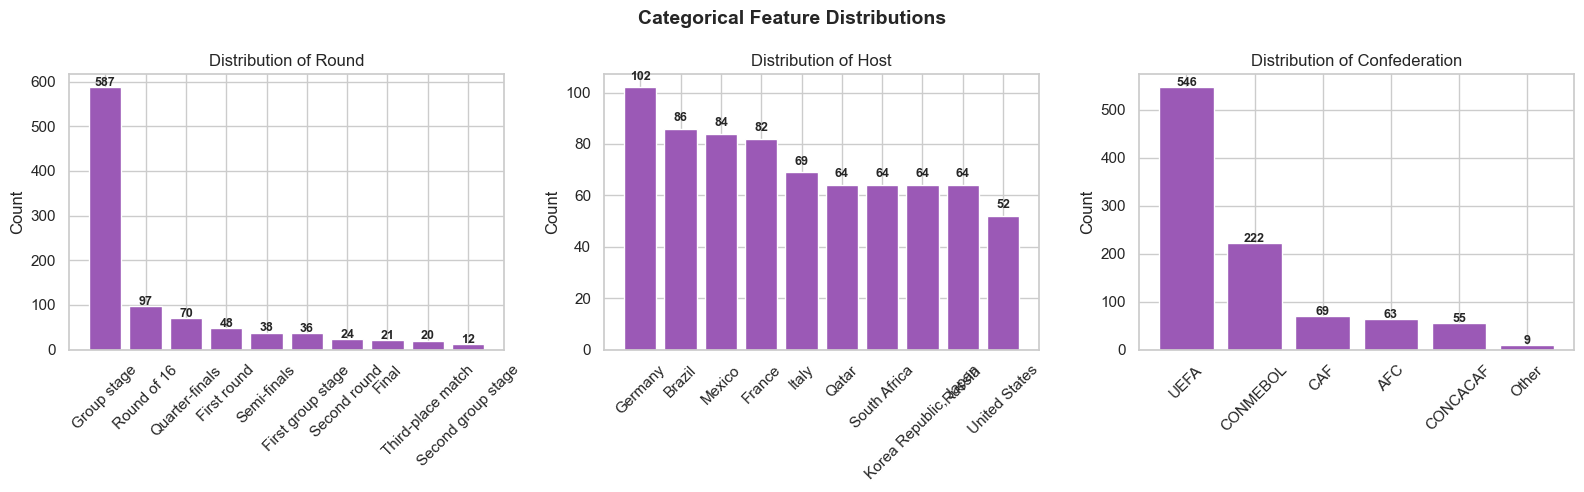

In [23]:
# Select categorical variables for analysis.
categorical_cols = ["Round", "Host", "Confederation"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(categorical_cols):
    counts = df[col].value_counts().head(10)
    axes[i].bar(counts.index.astype(str), counts.values,
                color="#9b59b6", edgecolor="white")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=45)
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 3, str(v), ha="center", fontweight="bold", fontsize=9)

plt.suptitle("Categorical Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

result,H,D,A
Round,,,
Group stage play-off,100.0%,0.0%,0.0%
Final stage,83.3%,16.7%,0.0%
Third-place match,75.0%,0.0%,25.0%
Round of 16,68.0%,15.5%,16.5%
Final,66.7%,14.3%,19.0%
Semi-finals,63.2%,13.2%,23.7%
Second round,62.5%,16.7%,20.8%
Quarter-finals,58.6%,22.9%,18.6%
First round,56.2%,31.2%,12.5%


<Figure size 1200x600 with 0 Axes>

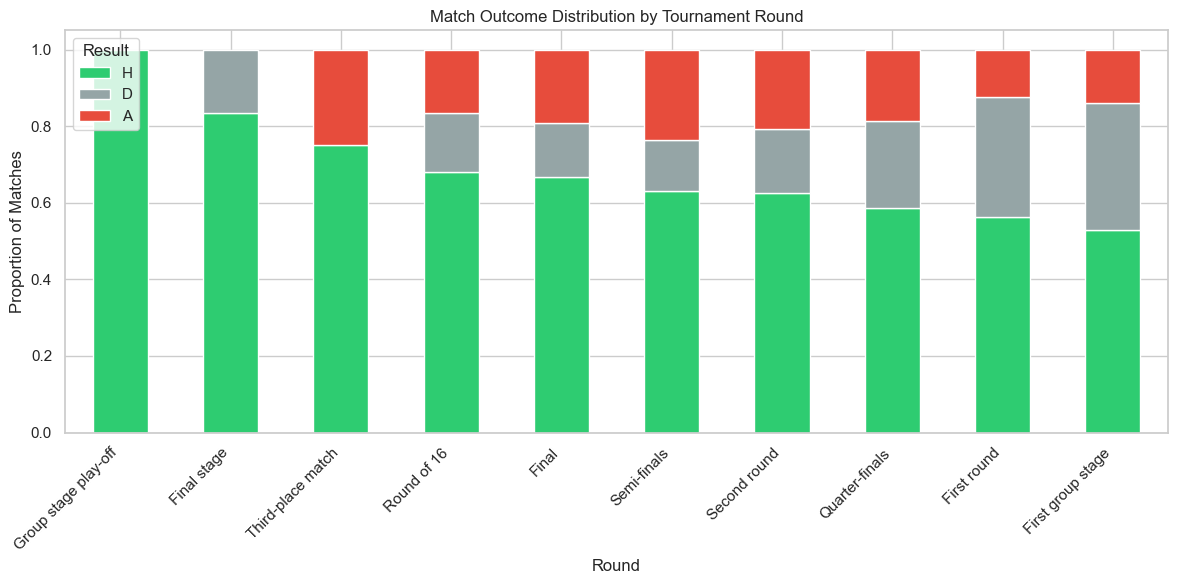

,Matches,Home Win Rate
Not host,882,53.9%
Host,82,69.5%


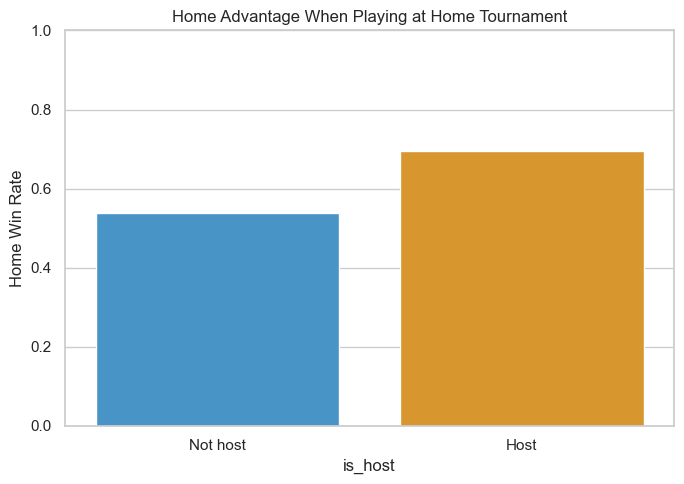

home_score              away_score              total_goals        \
            count  mean median      count  mean median       count  mean   
result                                                                     
A             218  0.50    0.0        218  2.18    2.0         218  2.68   
D             214  0.89    1.0        214  0.89    1.0         214  1.79   
H             532  2.66    2.0        532  0.64    0.5         532  3.30   

              Attendance                     
       median      count      mean   median  
result                                       
A         3.0        218  47829.26  42953.5  
D         2.0        214  44344.31  41469.0  
H         3.0        532  45360.81  42866.5

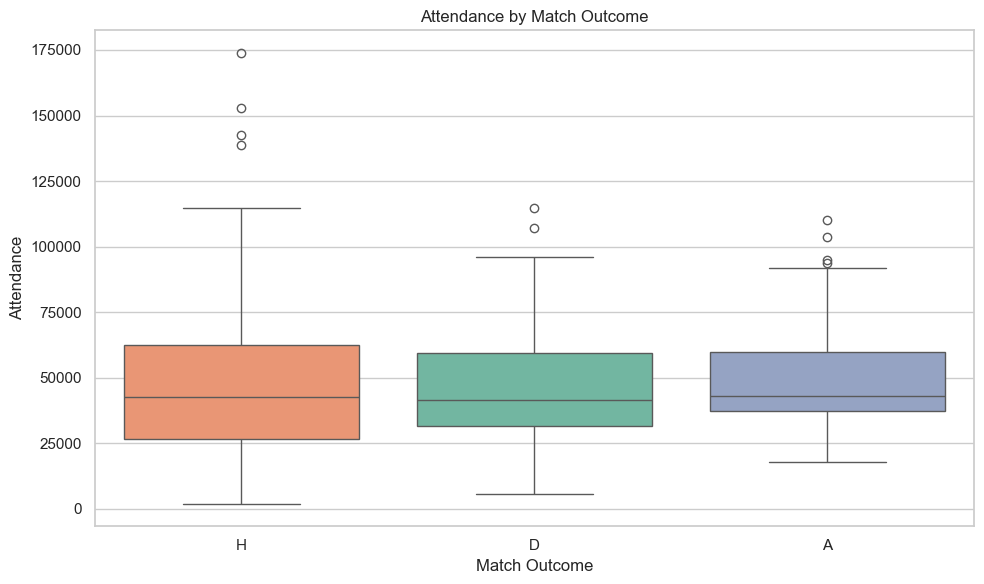

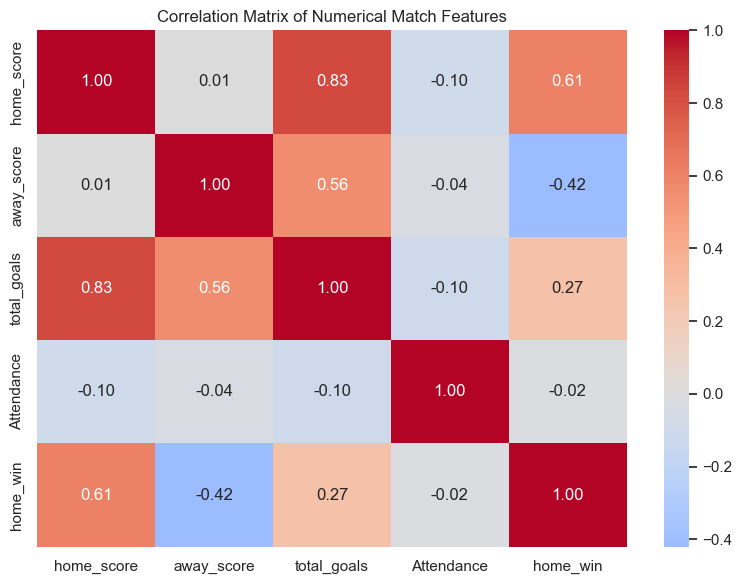

In [24]:
# Explore relationships between key variables.
# Bivariate Analysis
# Explore relationships between match outcomes and important match features.

from IPython.display import display

# Helper column: whether the home team was also the tournament host
df["is_host"] = (df["home_team"] == df["Host"]).astype(int)

# 1. Match outcome by tournament round
round_result = pd.crosstab(df["Round"], df["result"], normalize="index").reindex(columns=["H", "D", "A"], fill_value=0)
display(round_result.sort_values("H", ascending=False).head(15).style.format("{:.1%}"))

plt.figure(figsize=(12, 6))
round_result.sort_values("H", ascending=False).head(10).plot(
    kind="bar", stacked=True, figsize=(12, 6),
    color=["#2ecc71", "#95a5a6", "#e74c3c"]
)
plt.title("Match Outcome Distribution by Tournament Round")
plt.xlabel("Round")
plt.ylabel("Proportion of Matches")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Result")
plt.tight_layout()
plt.show()

# 2. Home-team win rate when the home team is the host
host_outcome = df.groupby("is_host")["home_win"].agg(["count", "mean"]).rename(columns={"count": "Matches", "mean": "Home Win Rate"})
host_outcome.index = ["Not host", "Host"]
display(host_outcome.style.format({"Home Win Rate": "{:.1%}"}))

plt.figure(figsize=(7, 5))
sns.barplot(data=df, x="is_host", y="home_win", estimator="mean", errorbar=None, palette=["#3498db", "#f39c12"], hue="is_host", legend=False)
plt.xticks([0, 1], ["Not host", "Host"])
plt.ylim(0, 1)
plt.ylabel("Home Win Rate")
plt.title("Home Advantage When Playing at Home Tournament")
plt.tight_layout()
plt.show()

# 3. Numerical relationships with match outcome
display(df.groupby("result")[["home_score", "away_score", "total_goals", "Attendance"]].agg(["count", "mean", "median"]).round(2))

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="result", y="Attendance", order=["H", "D", "A"], palette="Set2", hue="result", legend=False)
plt.title("Attendance by Match Outcome")
plt.xlabel("Match Outcome")
plt.ylabel("Attendance")
plt.tight_layout()
plt.show()

# 4. Correlation between numerical match variables
corr_cols = ["home_score", "away_score", "total_goals", "Attendance", "home_win"]
plt.figure(figsize=(8, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Matrix of Numerical Match Features")
plt.tight_layout()
plt.show()

,home_score,away_score,home_xg,away_xg,home_penalty,away_penalty,total_goals,Attendance,is_host
home_score,1.000,0.005,0.621,-0.133,0.292,0.163,0.831,-0.096,0.061
away_score,0.005,1.000,0.038,0.475,0.292,0.163,0.560,-0.036,-0.044
home_xg,0.621,0.038,1.000,-0.267,0.222,-0.163,0.541,0.007,-0.093
away_xg,-0.133,0.475,-0.267,1.000,0.467,0.209,0.158,-0.071,-0.033
home_penalty,0.292,0.292,0.222,0.467,1.000,-0.012,0.292,0.027,-0.011
away_penalty,0.163,0.163,-0.163,0.209,-0.012,1.000,0.163,0.076,-0.018
total_goals,0.831,0.560,0.541,0.158,0.292,0.163,1.000,-0.099,0.026
Attendance,-0.096,-0.036,0.007,-0.071,0.027,0.076,-0.099,1.000,0.273
is_host,0.061,-0.044,-0.093,-0.033,-0.011,-0.018,0.026,0.273,1.000


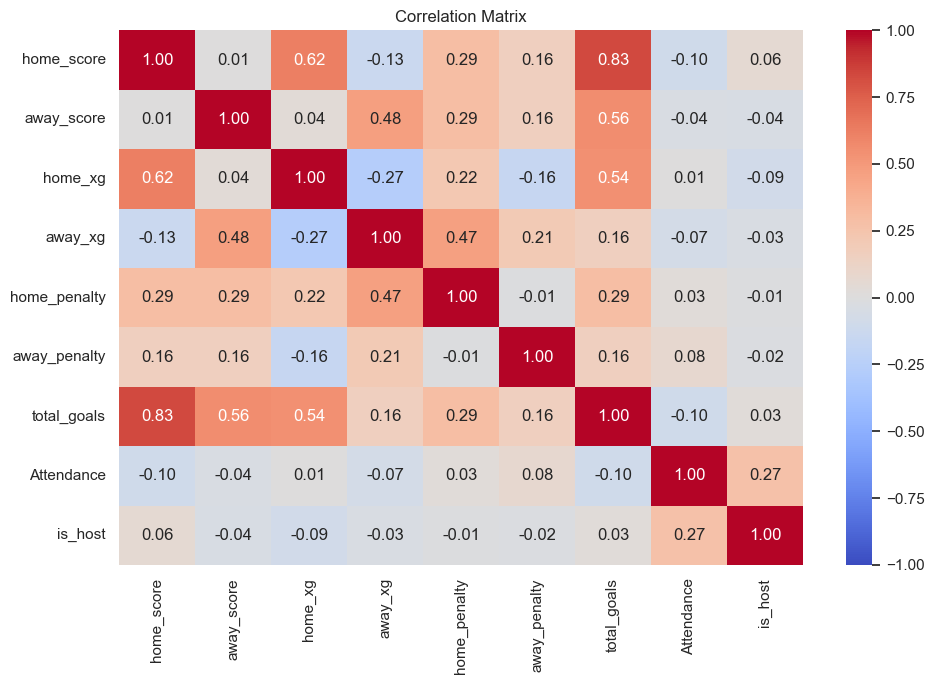

Strongest unique correlations:


Absolute Pearson correlation
home_score total_goals                      0.831321
           home_xg                          0.621172
away_score total_goals                      0.560121
home_xg    total_goals                      0.541246
away_score away_xg                          0.475121

In [25]:
# Analyze correlations among numerical variables.
# Correlation Analysis
correlation_features = [
    col for col in [
        "home_score", "away_score", "home_xg", "away_xg",
        "home_penalty", "away_penalty", "total_goals", "Attendance", "is_host"
    ] if col in df.columns
]

correlation_matrix = df[correlation_features].apply(pd.to_numeric, errors="coerce").corr()
display(correlation_matrix.round(3))

plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

pairs = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)).stack()
print("Strongest unique correlations:")
display(pairs.abs().sort_values(ascending=False).head(5).to_frame("Absolute Pearson correlation"))


## Additional football-specific analysis

### Code specification for the analysis sections

**Imports and setup.** The first code cell imports pandas for tabular data, NumPy for conditional calculations, Matplotlib and Seaborn for visualizations. The plotting defaults make all figures consistent and readable.

**Loading the data.** The two CSV files are read with relative paths so the notebook can be run from the `notebooks` directory. `head()` confirms that the files were loaded correctly before analysis begins.

**Dataset overview.** `info()` reports row counts, column names, data types, and non-null values. Descriptive summaries provide a first check of numerical ranges and categorical values. These checks help identify columns that need conversion or cleaning.

**Missing values.** The missing-value function calculates both the number and percentage of missing observations. The chart emphasizes columns requiring attention. Expected-goals and penalty fields may be unavailable for older tournaments, so missingness should be treated as a historical coverage issue rather than automatically as zero.

**Target construction.** `result` labels each match as home win (`H`), draw (`D`), or away win (`A`). `home_win` converts this into a binary target. These variables are derived from final scores and must not be used as predictors when predicting the match outcome.

**Univariate analysis.** Histograms show the distributions of scores, total goals, and attendance. Mean and median lines make skewness visible. Bar charts show the frequency of rounds, hosts, and confederations.

**Bivariate analysis.** Cross-tabulations and grouped summaries compare outcomes by round and host status. Boxplots compare attendance across outcomes, while the heatmap summarizes linear relationships among numerical variables.

**Time and team analysis.** Yearly summaries show changes in scoring and home-win rates. The team summary combines home and away appearances to calculate matches, goals scored, goals conceded, and goal difference. Results should be read together with sample size.

**Correlation analysis.** Pearson correlations describe linear association, not causation. Correlations involving `total_goals` and the final scores are expected because `total_goals` is calculated from those scores. Such variables require special care in a predictive model.

,matches,avg_goals,home_win_rate
year_num,,,
1966,32,2.781,0.844
1970,32,2.969,0.844
1974,38,2.553,0.395
1978,38,2.684,0.763
1982,52,2.808,0.500
1986,52,2.538,0.404
1990,52,2.212,0.519
1994,52,2.712,0.500
1998,64,2.672,0.438


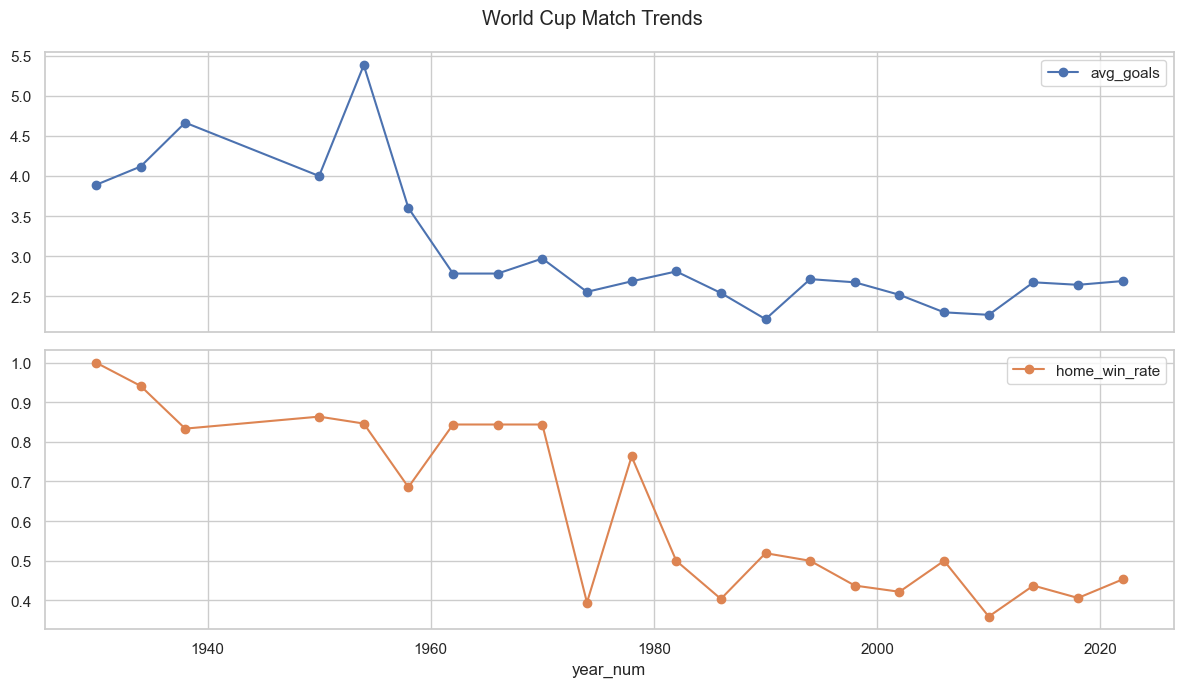

,matches,goals_for,goals_against,goal_difference
Brazil,114,237,108,129
Argentina,88,152,101,51
Italy,83,128,77,51
England,74,104,68,36
France,73,136,85,51
Spain,67,108,75,33
Mexico,60,62,101,-39
Uruguay,59,89,76,13
Germany,56,126,67,59
West Germany,56,106,63,43


In [26]:
# Analyze time trends and summarize team-level results.
# Time trends and team-level summaries
year_col = next((c for c in ["year", "Year", "date"] if c in df.columns), None)
if year_col:
    years = pd.to_numeric(df[year_col].astype(str).str[:4], errors="coerce")
    yearly = df.assign(year_num=years).groupby("year_num").agg(
        matches=("result", "size"), avg_goals=("total_goals", "mean"),
        home_win_rate=("home_win", "mean")
    )
    display(yearly.tail(15).round(3))
    yearly[["avg_goals", "home_win_rate"]].plot(subplots=True, figsize=(12, 7), marker="o", title="World Cup Match Trends")
    plt.tight_layout(); plt.show()

team_summary = pd.concat([
    df.groupby("home_team").agg(matches=("result", "size"), goals_for=("home_score", "sum"), goals_against=("away_score", "sum")),
    df.groupby("away_team").agg(matches=("result", "size"), goals_for=("away_score", "sum"), goals_against=("home_score", "sum"))
]).groupby(level=0).sum()
team_summary["goal_difference"] = team_summary.goals_for - team_summary.goals_against
display(team_summary.sort_values(["matches", "goal_difference"], ascending=False).head(15))

In [ ]:
# Relationship between match data and playoff-team results
playoff_summary = df2.groupby('Year').agg(playoff_teams=('Team','nunique'), best_position=('Final_Position','min')).reset_index()
match_summary = df.groupby('Year').size().rename('matches').reset_index()
relationship = match_summary.merge(playoff_summary,on='Year',how='left')
display(relationship.tail(15))
team_pairs = pd.concat([df[['Year','home_team']].rename(columns={'home_team':'Team'}),df[['Year','away_team']].rename(columns={'away_team':'Team'})]).drop_duplicates()
linked = team_pairs.merge(df2[['Year','Team','Final_Position']],on=['Year','Team'],how='inner')
print(f'Year-team pairs linked to playoff results: {len(linked)} of {len(team_pairs)}')
display(linked.head())


**Interpretation:** Yearly averages show how scoring and home advantage change over time. The team table gives a compact view of participation and goal difference; it should be interpreted alongside the number of matches because teams with more appearances have more opportunity to accumulate goals.

## Summary of EDA Findings

| **Finding** | **Detail** |
| --- | --- |
| **Dataset scope** | 964 World Cup matches from 1930-2022 |
| **Match outcomes** | Home wins: ~55%; draws: ~22%; away wins: ~23% |
| **Home advantage** | Home teams won more often than away teams |
| **Missing data** | Expected-goals fields are missing for ~87% of matches; this should be considered before modeling |
| **Categorical features** | `Round`, `Host`, and `Confederation` are useful low-cardinality features for analysis |
| **Confederations** | UEFA and CONMEBOL account for most matches in the dataset |
| **Goals** | `total_goals` is strongly correlated with `home_score` (Pearson correlation ~0.83) |
| **Expected goals** | `home_xg` and `away_xg` show positive relationships with the corresponding scores |
| **Redundant features** | `total_goals` overlaps with home and away scores because it is calculated from them |
| **Modeling consideration** | Correlation shows association, not causation; missing values and redundant features should be handled before modeling |
